# High-yield munis: a 9% yield hiding behind a tax break 🏛️
### The high-yield muni credit premium — tested live, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Credit + tax wrapper?: Half true](https://img.shields.io/badge/Credit_%2B_tax_wrapper%3F-Half_true-8b949e?style=flat-square)

A *municipal bond* is a loan to a city, school district or toll road. Its magic trick: the interest is **exempt from federal income tax**. A *high-yield* muni is one from a shakier issuer, so it pays a fatter coupon. Put those together and you get a fund (HYD) advertising a yield that looks small on paper — until you remember a top-bracket investor keeps **all** of it while paying tax on ordinary junk bonds.

The pitch has two parts, and they are **not** equally true:

1. **The tax wrapper** — is a high-yield muni's *tax-equivalent* yield really higher than taxable junk? (Spoiler: **yes, and it's arithmetic**.)
2. **The credit premium** — does high-yield muni actually *out-earn* plain investment-grade muni for the extra risk, reliably? (Spoiler: **thinly, and it falls apart in a crisis**.)

We read the live tape: real, fee-charging ETFs since 2009.

> 📓 **Plain-language layer.** Want the regressions and robustness checks? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it, from **total-return, net-of-fee** ETF prices. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hy_muni import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_prices()                       # total-return closes, frozen as-of
    PR = data.load_price_only()                   # price-only closes (income leg)
    M = st.monthly_returns(PX, asof=data.AS_OF)
    INC = st.monthly_income(PX, PR, asof=data.AS_OF)
    MC = st.align_common(M, ["HYD", "MUB", "TFI", "HYG", "BIL"])   # HYD era
    RATE = data.TOP_MARGINAL_RATE
else:
    PX = PR = M = INC = MC = None
    RATE = 0.408
print("real ETF cache present:", HAVE_REAL,
      "| HYD-era months:", (0 if MC is None else len(MC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': 'db0172501766', 'start': '2009-03', 'end': '2026-06', 'n_months': 208, 'years': 17.3, 'rate': 40.8, 'spread_bps': 20.21, 'spread_t': 1.8, 'spread_pp': 2.43, 'boot_lo': -1.44, 'boot_hi': 42.23, 'boot_fracneg': 0.036, 'ann': {'HYD': 5.38, 'MUB': 3.2, 'TFI': 3.01, 'HYG': 7.26, 'BIL': 1.25}, 'sharpe': {'HYD': 0.478, 'MUB': 0.408, 'TFI': 0.341, 'HYG': 0.732}, 'sharpe_adv': 0.069, 'eras': [('2009-2016', 27.4, 1.85, 94), ('2017-2026', 14.3, 0.91, 114), ('2020 COVID', -18.4, -0.15, 12), ('2022 rate shock', -78.0, -4.35, 12)], 'halves': [('2009-2017', 1.0, 0.87, 0.13), ('2018-2026', 0.11, -0.04, 0.15)], 'income': {'HYD': 5.43, 'MUB': 2.71, 'HYG': 6.04}, 'tey': 9.17, 'aftertax_ann': {'HYD': 5.38, 'MUB': 3.2, 'HYG': 4.67}, 'aftertax_sharpe': {'HYD': 0.53, 'MUB': 0.51, 'HYG': 0.5}, 'dd': {'HYD': -35.6, 'MUB': -13.7, 'HYG': -22.0}, 'dd_dates': {'HYD': '2020-02-26 - 2020-03-18', 'MUB': '2020-03-09 - 2020-03-19', 'HYG': '2020-02-13 - 2020-03-23'}, 'costs': [(5.0, 0.6, 242), (15.0, 1.7, 241), (30.0, 3.5, 239)], 'gross_bps': 243, 'syn': [(0.0, 5.18, 1.13, -3.5, 14.1, 0.128), (3.0, 30.18, 6.59, 21.5, 39.1, 0.0)]}


real ETF cache present: True | HYD-era months: 208


## The answer first

| Question | Answer |
|---|---|
| Is the tax-free yield really worth more than taxable junk? | **Yes — mechanically.** HYD's **tax-equivalent yield is ~9.2%** vs **6.0%** for taxable HY, and its *after-tax* return actually beats taxable junk (**5.4%** vs **4.7%**/yr). |
| Does HY-muni beat plain (safe) muni for the extra risk? | **Only weakly.** **+2.4%/yr** on average — but the statistics are borderline (below our bar), and it turns sharply *negative* exactly when markets seize up. |
| Can you collect it cheaply? | **The trade is cheap** (one fund swap), but the *edge* is thin and fragile, so it isn't a green light. |
| What's the catch? | **The crash.** In March 2020 HYD fell **-36%** while safe muni fell only **-14%**; in 2022 HY-muni *lost* to safe muni by nearly **1% per month**. |

## 1 · The claim

> *"High-yield munis pay a fat spread over investment-grade munis — a credit premium — and because the coupons are federally tax-free, a top-bracket investor earns a tax-equivalent yield that buries taxable junk bonds."*

Two mechanisms are bundled here. One is **tax law** (muni coupons are exempt — not an opinion). The other is a **risk premium** (you get paid for lending to shakier issuers in a thin, illiquid market). Bundling them is how a marketing deck turns a borderline credit bet into a headline yield. Our job is to un-bundle them.

## 2 · So what?

If both legs held, a top-bracket investor would have a rare free lunch: a high tax-equivalent yield *and* a paid credit premium, collectible in one ETF. If only the **tax** leg holds, HY-muni is still a smart place to park taxable-account money — but you're buying a *tax break*, not a *credit edge*, and you must respect the crash. Telling the two apart is the whole point.

## 3 · How would we even know?

Take every complete month since the HY-muni ETF listed (**2009-03 → 2026-06, 208 months**) and:

1. **Measure the credit spread** — HYD minus MUB (safe muni), with statistics that aren't fooled by streaky months, and a bootstrap confidence band.
2. **Check the crises** — 2020 and 2022, where muni illiquidity is supposed to bite.
3. **Do the tax math** — back out each fund's coupon, gross up the muni's tax-free yield, and race the *after-tax* returns against taxable junk (HYG).
4. **Price the pain** — the drawdown, and the cost of the trade.

## 4 · The teardown — let's actually look

**Growth of $100** in high-yield muni vs plain investment-grade muni, since both traded.

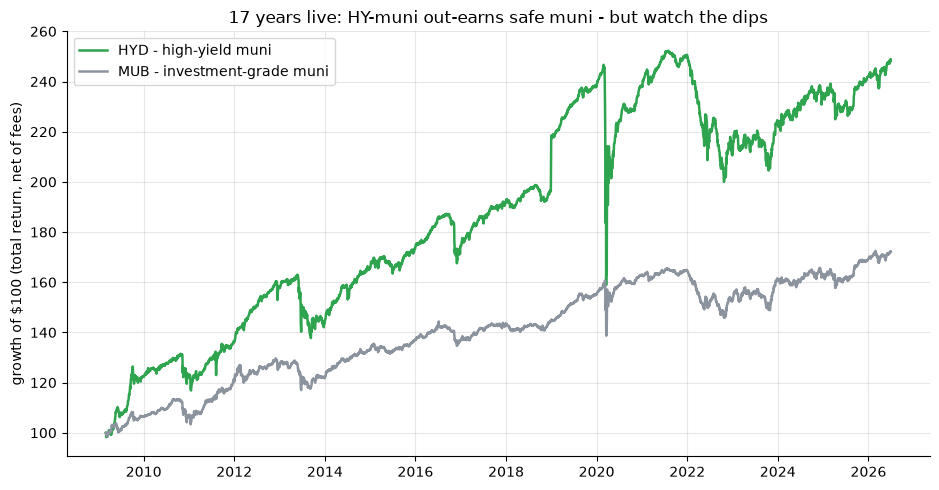

final: HYD $248  vs  MUB $172


In [2]:
if HAVE_REAL:
    px = PX[["HYD", "MUB"]].loc["2009-03-01":].dropna()
    g = 100.0 * px / px.iloc[0]
    fig, ax = plt.subplots()
    ax.plot(g.index, g["HYD"], c=GREEN, lw=1.8, label="HYD - high-yield muni")
    ax.plot(g.index, g["MUB"], c=GREY, lw=1.8, label="MUB - investment-grade muni")
    ax.set_ylabel("growth of $100 (total return, net of fees)")
    ax.set_title("17 years live: HY-muni out-earns safe muni - but watch the dips")
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'final: HYD ${g["HYD"].iloc[-1]:.0f}  vs  MUB ${g["MUB"].iloc[-1]:.0f}')
else:
    print('cache missing - frozen numbers:', R['ann'])

HY-muni compounds at **5.38%/yr** vs **3.20%/yr** for safe muni — a gap of **+2.4 pp/yr** for 17 years. But the quants notebook shows the gap is **statistically thin** (HAC *t* = 1.80, *below* the desk's *t* ≥ 2 bar) and its bootstrap confidence band touches zero. Real direction, weak certainty.

**The tax break — where the yield actually comes from.** Let's back out each fund's coupon (income) and gross up the muni's tax-free yield to a *tax-equivalent* yield a top-bracket investor would compare against taxable junk.

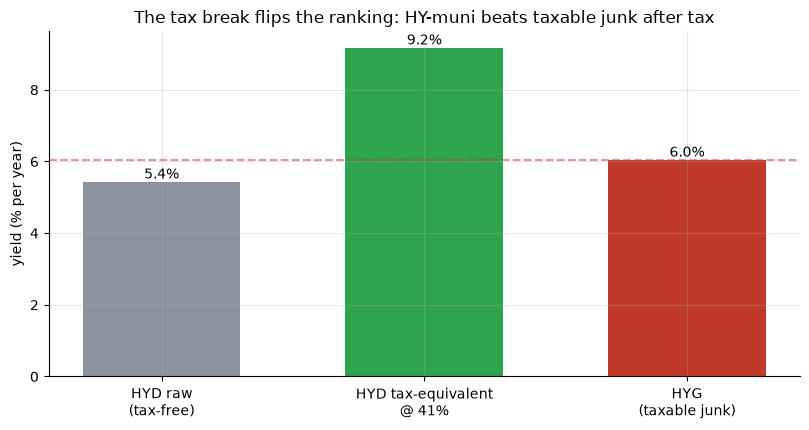

HYD raw 5.43%  ->  tax-equivalent 9.17%   vs  HYG taxable 6.04%


In [3]:
if HAVE_REAL:
    iy = st.income_yields(INC.loc[MC.index], ['HYD', 'MUB', 'HYG'])
    tey = st.tax_equivalent_yield(iy['HYD'], RATE)
    hyg_y = iy['HYG']
else:
    iy = R['income']; tey = R['tey']; hyg_y = R['income']['HYG']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
bars = ['HYD raw\n(tax-free)', f'HYD tax-equivalent\n@ {RATE*100:.0f}%', 'HYG\n(taxable junk)']
vals = [iy['HYD'], tey, hyg_y]
ax.bar(bars, vals, color=[GREY, GREEN, RED], width=.6)
for i, v in enumerate(vals): ax.annotate(f'{v:.1f}%', (i, v), ha='center', va='bottom')
ax.axhline(hyg_y, ls='--', c=RED, alpha=.5)
ax.set_ylabel('yield (% per year)')
ax.set_title('The tax break flips the ranking: HY-muni beats taxable junk after tax')
plt.tight_layout(); plt.show()
print(f'HYD raw {iy["HYD"]:.2f}%  ->  tax-equivalent {tey:.2f}%   vs  HYG taxable {hyg_y:.2f}%')

On paper taxable junk (HYG) yields **6.0%** and HY-muni only **5.4%** — junk looks better. But once you count the tax break, HY-muni's **tax-equivalent yield is ~9.2%**. That's the whole trick, and it's just arithmetic: `yield / (1 − tax rate)`. This part of the claim is **real and mechanical**.

**The catch — the crash you carry.** The thin muni-junk market gaps hard when liquidity vanishes. Here is the drawdown bill around COVID.

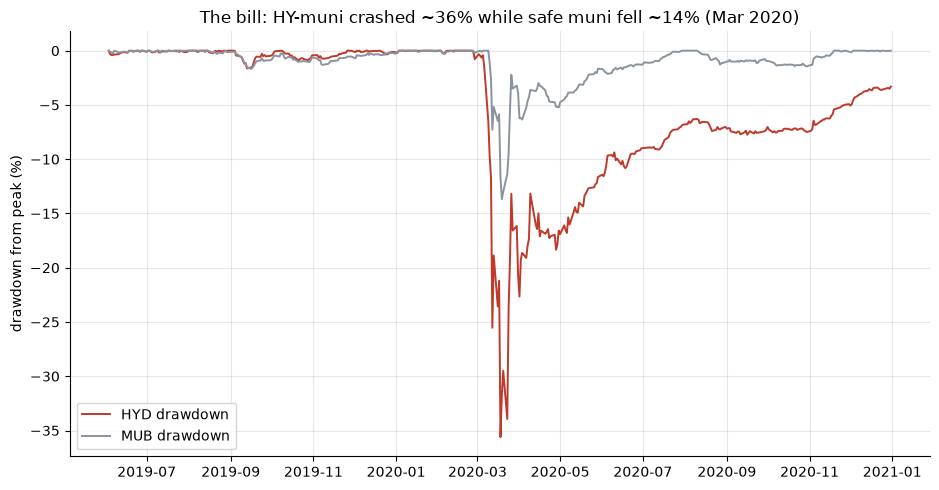

max DD in window: HYD -35.6%  vs  MUB -13.7%


In [4]:
if HAVE_REAL:
    px = PX[["HYD", "MUB"]].loc["2019-06-01":"2020-12-31"].dropna()
    dd = px / px.cummax() - 1.0
    fig, ax = plt.subplots()
    ax.plot(dd.index, dd["HYD"]*100, c=RED, lw=1.4, label="HYD drawdown")
    ax.plot(dd.index, dd["MUB"]*100, c=GREY, lw=1.4, label="MUB drawdown")
    ax.set_ylabel("drawdown from peak (%)")
    ax.set_title("The bill: HY-muni crashed ~36% while safe muni fell ~14% (Mar 2020)")
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'max DD in window: HYD {dd["HYD"].min()*100:.1f}%  vs  MUB {dd["MUB"].min()*100:.1f}%')
else:
    print('cache missing - frozen numbers:', R['dd'])

In March 2020 HY-muni fell **-36%** vs **-14%** for safe muni — and in 2022 the credit spread went *negative* by nearly 1%/month. That's the price of admission: when everyone wants out of the thin muni-junk market at once, you're the one holding it. The premium is your pay for that job — and it isn't reliable.

## 5 · The verdict

- **Signal — Weak.** +2.4%/yr over safe muni for 17 live years, but statistically thin (*t* = 1.80, below the bar; confidence band touches zero) and it inverts hard in crises.
- **Tradability — Fragile.** The trade is cheap (one fund swap) and the **tax wrapper is genuinely valuable** (tax-equivalent yield ~9.2% vs 6.0%; after-tax 5.4% vs 4.7%) — but the credit edge is thin, crisis-fragile, and only helps a top-bracket taxable investor.
- **"Credit premium + tax wrapper"? — Half true.** The tax wrapper is real. The credit premium over safe muni doesn't reliably clear the bar.

Honest bottom line: buy high-yield muni for the **tax-equivalent yield** if you're top-bracket and taxable — not for a dependable, all-weather credit edge over safe munis.

## 6 · Going further 🚪

- **Why is the credit premium so thin here?** Munis default *rarely*, so most of the spread is a **liquidity** premium — which is exactly the thing that vanishes (and reverses) in a panic. You're paid in calm and taxed in crisis.
- **Why does the tax leg still matter?** Because it's law, not luck. As long as muni coupons are federally exempt and you're in a high bracket in a taxable account, the tax-equivalent-yield gap is real every single month.
- **Related desks:** [Study 610 — Fallen-Angels](../../610-fallen-angels-premium/) is the *taxable* cousin (a within-junk selection premium that **does** clear); [Study 576 — Muni-Treasury-Ratio](../../576-muni-treasury-ratio/) and [Study 616 — Muni-CEF-Tax-Loss](../../616-muni-cef-tax-loss/) test other muni folklore.

*Think the credit premium is only crushed by the 2022 shock? Re-run the era cut without 2022 in the quants notebook and see how much of the thinness is that one year.*